# 问题一：分类变量与表面风化

分析 `纹饰`、`类型`、`颜色`、`表面风化` 的两两关联。关联强度使用小样本偏差校正 Cramér's V；卡方 p 值仅在期望频数条件满足时可靠。颜色缺失值保留为“未知”。

In [1]:
from pathlib import Path

from cumcm2022c.analysis.categorical import (
    association_matrix,
    pairwise_categorical_associations,
    prepare_categorical_data,
)
from cumcm2022c.data.load import load_table
from cumcm2022c.visualization.categorical import (
    configure_chinese_fonts,
    plot_association_heatmaps,
    plot_category_counts,
    plot_weathering_proportions,
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
CATEGORICAL_COLUMNS = ["纹饰", "类型", "颜色", "表面风化"]
PREDICTORS = CATEGORICAL_COLUMNS[:3]
configure_chinese_fonts()

'Noto Sans CJK SC'

In [2]:
raw = load_table("form_1", DATA_DIR)
categorical = prepare_categorical_data(raw, CATEGORICAL_COLUMNS)
{
    "样本数": len(categorical),
    "颜色未知数": int(categorical["颜色"].eq("未知").sum()),
    "各变量类别数": categorical.nunique().to_dict(),
}

{'样本数': 58, '颜色未知数': 4, '各变量类别数': {'纹饰': 3, '类型': 2, '颜色': 9, '表面风化': 2}}

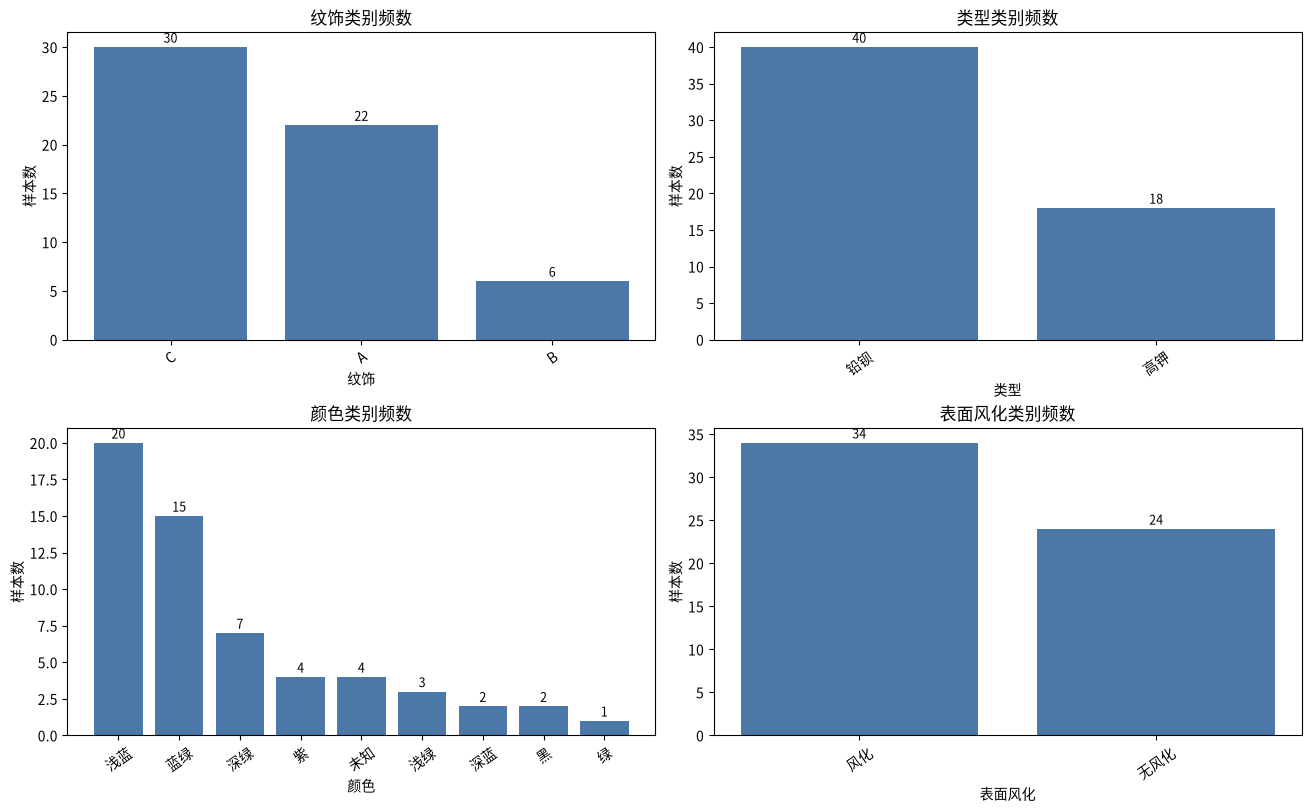

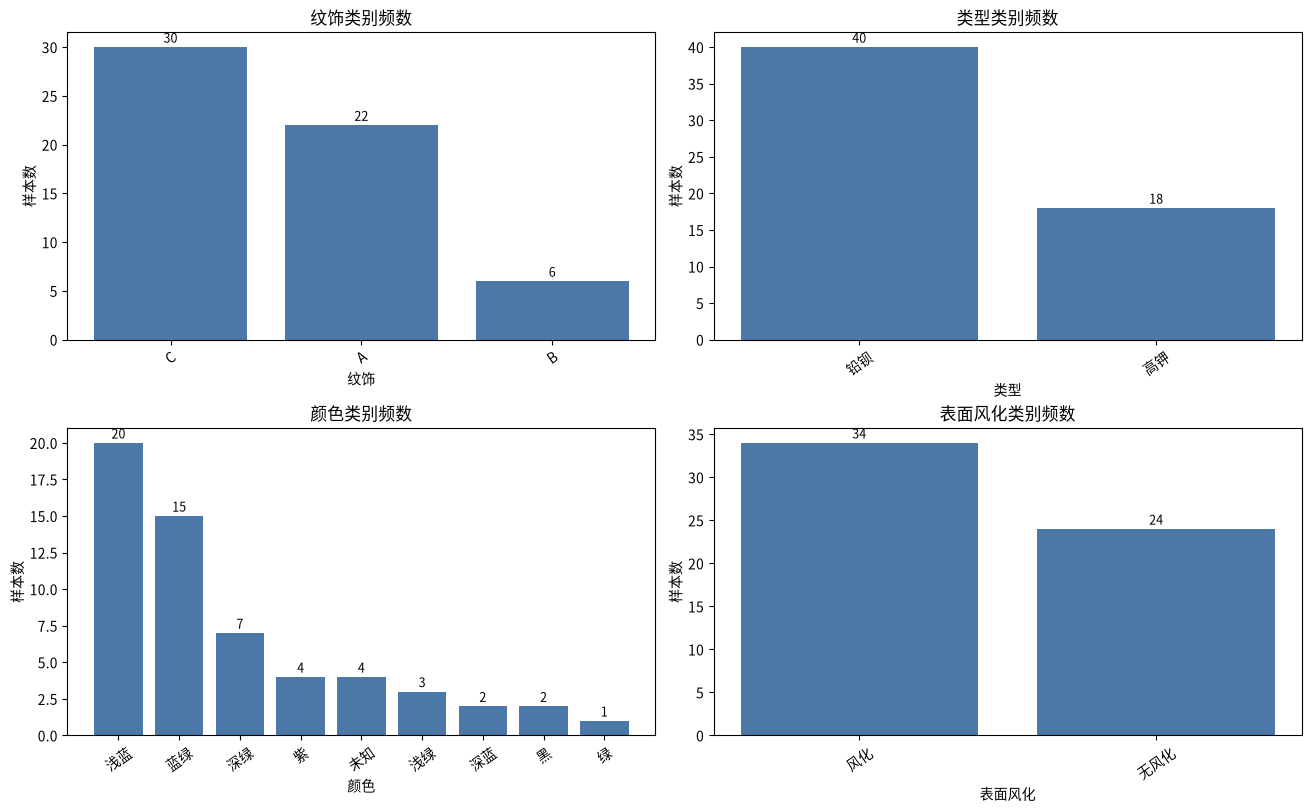

In [3]:
count_figure, _ = plot_category_counts(categorical, CATEGORICAL_COLUMNS)
count_figure

In [4]:
associations = pairwise_categorical_associations(categorical, CATEGORICAL_COLUMNS)
associations.style.format(
    {
        "chi2": "{:.3f}",
        "p_value": "{:.4g}",
        "cramers_v": "{:.3f}",
        "min_expected": "{:.3f}",
        "low_expected_ratio": "{:.1%}",
    }
)

,variable_1,variable_2,n,chi2,dof,p_value,cramers_v,min_expected,low_expected_ratio,chi_square_reliable
0,纹饰,类型,58,15.185,2,0.0005041,0.480,1.862,33.3%,False
1,纹饰,颜色,58,39.651,16,0.0008753,0.457,0.103,85.2%,False
2,纹饰,表面风化,58,4.957,2,0.08389,0.226,2.483,33.3%,False
3,类型,颜色,58,25.495,8,0.001281,0.552,0.310,83.3%,False
4,类型,表面风化,58,6.880,1,0.008715,0.321,7.448,0.0%,True
5,颜色,表面风化,58,9.432,8,0.3071,0.151,0.414,77.8%,False


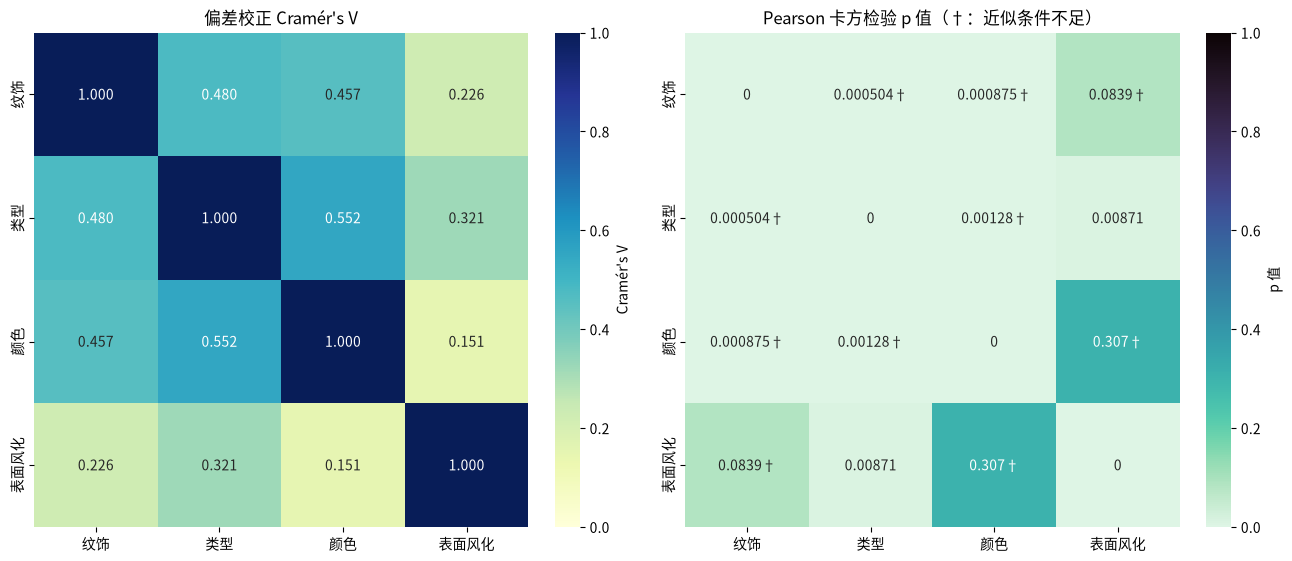

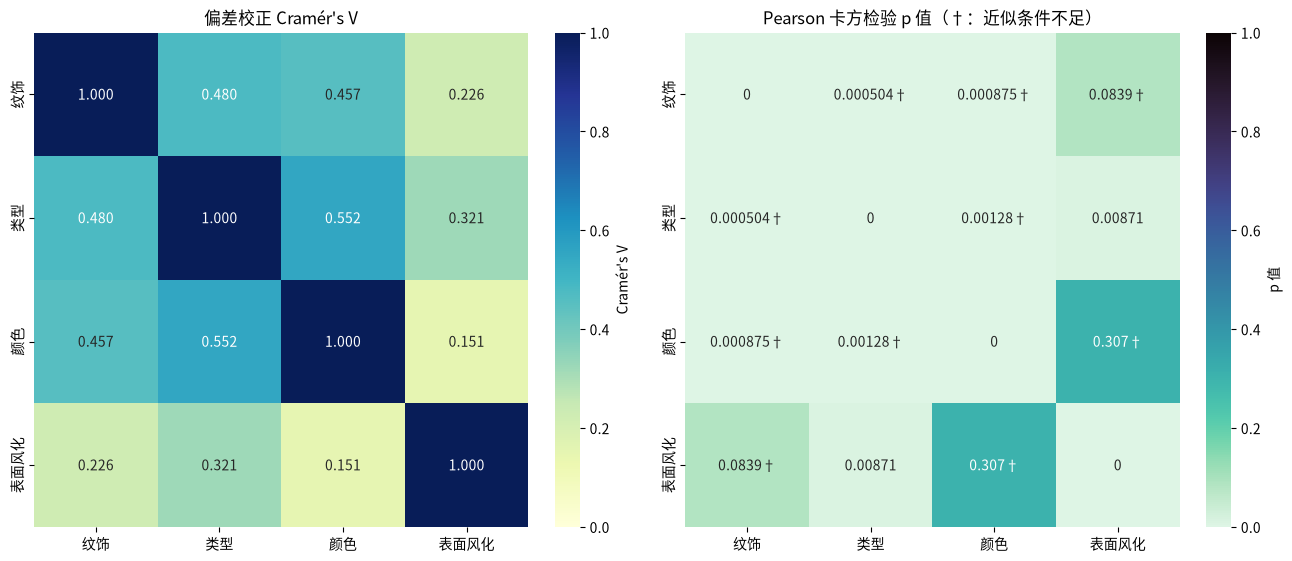

In [5]:
v_matrix = association_matrix(associations, CATEGORICAL_COLUMNS, "cramers_v")
p_matrix = association_matrix(associations, CATEGORICAL_COLUMNS, "p_value")
reliability_matrix = association_matrix(associations, CATEGORICAL_COLUMNS, "chi_square_reliable")
heatmap_figure, _ = plot_association_heatmaps(v_matrix, p_matrix, reliability_matrix)
heatmap_figure

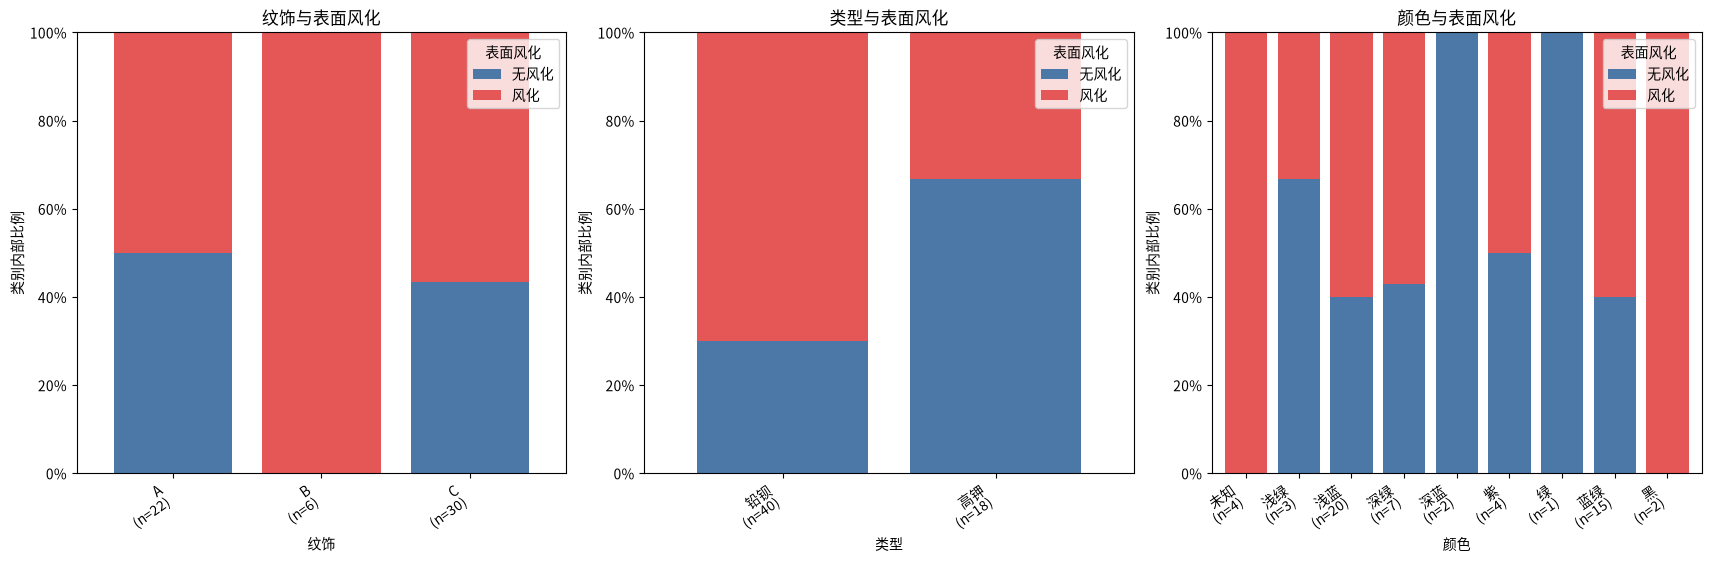

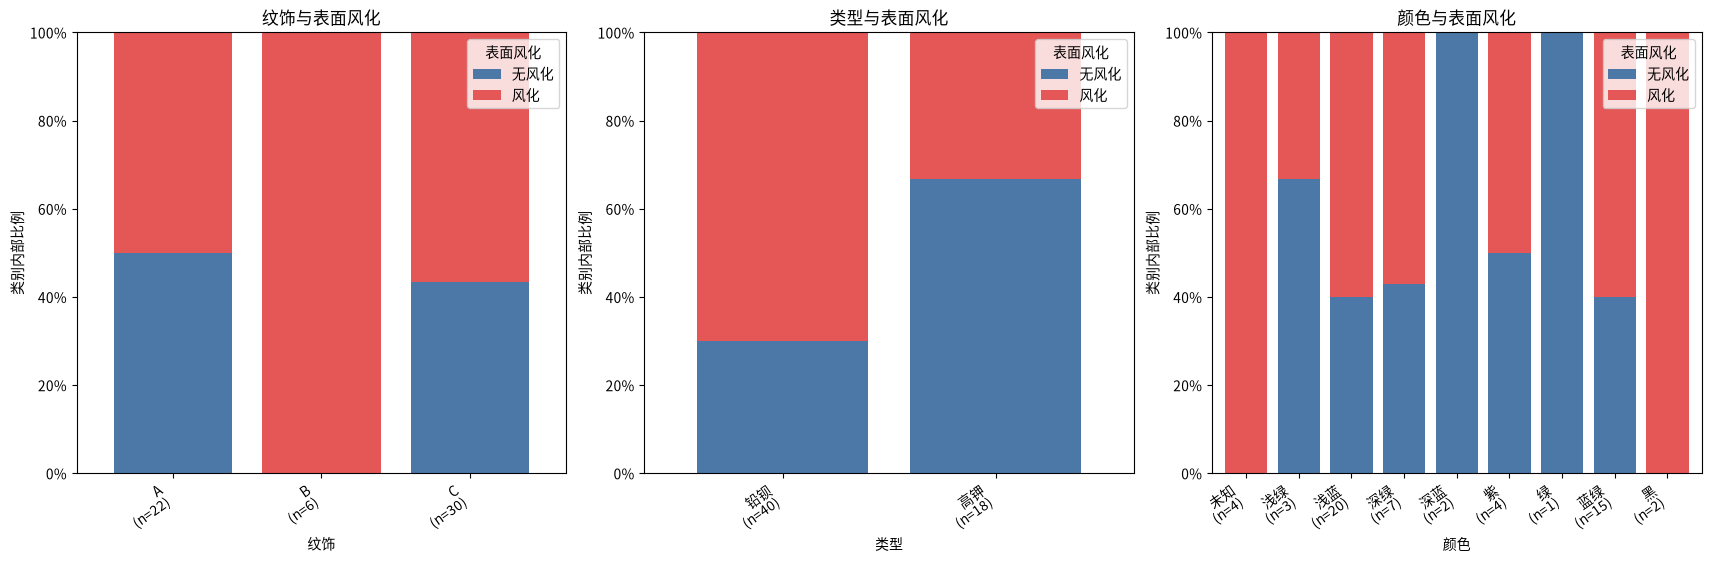

In [6]:
weathering_figure, _ = plot_weathering_proportions(categorical, PREDICTORS)
weathering_figure